# Intelligent Laptop Price Prediction and Value Analysis Using Machine Learning

**Course:** BASCE301 — Exploratory Data Analysis  
**Team:** Aarav Sijariya (25BDS0058) · Sulagna Chowdhury (25BCE0979) · Tejaswini Jaiswal (25BDS0054)  
**Guide:** Padma Priya M  
**Dataset:** Kaggle **Brand Laptops Dataset** (`laptops_india.csv`) — 991 laptop listings, 22 attributes  
**Currency:** Indian Rupees (INR)

### Project workflow
`Dataset Collection → Data Understanding → Cleaning & Preprocessing → Descriptive Statistics → Univariate EDA → Bivariate EDA → Multivariate / Correlation Analysis → Outlier Analysis → Feature Engineering → Model Comparison → Evaluation → Explainability → Fair-Price Estimation → Value Analysis`

This notebook is the final 991-row pipeline and is aligned with the course-project requirements and the project proposal.

In [1]:
# Colab setup (uncomment if required)
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost -q

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 1. Dataset Loading and Data Understanding

The project proposal identifies the Kaggle **Brand Laptops Dataset** as the project dataset. The dataset contains laptop specifications and listed prices, allowing both numerical and categorical EDA. The `Model` column is a listing title rather than a generalizable hardware feature, while `index` is only a row identifier.

In [2]:
df_raw = pd.read_csv("laptops_india.csv")

print("Dataset shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())

display(df_raw.head())

Dataset shape: (991, 22)

Columns:
['index', 'brand', 'Model', 'Price', 'Rating', 'processor_brand', 'processor_tier', 'num_cores', 'num_threads', 'ram_memory', 'primary_storage_type', 'primary_storage_capacity', 'secondary_storage_type', 'secondary_storage_capacity', 'gpu_brand', 'gpu_type', 'is_touch_screen', 'display_size', 'resolution_width', 'resolution_height', 'OS', 'year_of_warranty']


,index,brand,Model,Price,Rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,primary_storage_type,primary_storage_capacity,secondary_storage_type,secondary_storage_capacity,gpu_brand,gpu_type,is_touch_screen,display_size,resolution_width,resolution_height,OS,year_of_warranty
0,1,tecno,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990,63,intel,core i3,2,4,8,SSD,512,No secondary storage,0,intel,integrated,False,15.6,1920,1080,windows,1
1,2,tecno,Tecno Megabook T1 Laptop (11th Gen Core i7/ 16...,35990,67,intel,core i7,4,8,16,SSD,1024,No secondary storage,0,intel,integrated,False,15.6,1920,1080,windows,1
2,3,hp,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,51100,73,amd,ryzen 5,6,12,8,SSD,512,No secondary storage,0,amd,dedicated,False,15.6,1920,1080,windows,1
3,4,acer,Acer Extensa EX214-53 Laptop (12th Gen Core i5...,39990,62,intel,core i5,12,16,8,SSD,512,No secondary storage,0,intel,integrated,False,14.0,1920,1080,windows,1
4,5,lenovo,Lenovo V15 82KDA01BIH Laptop (AMD Ryzen 3 5300...,28580,62,amd,ryzen 3,4,8,8,SSD,512,No secondary storage,0,amd,integrated,False,15.6,1920,1080,windows,1


In [3]:
print("Data types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nNumerical summary:")
display(df_raw.describe().T)

print("\nCategorical summary:")
display(df_raw.describe(include="object").T)

Data types:


,dtype
index,int64
brand,object
Model,object
Price,int64
Rating,int64
processor_brand,object
processor_tier,object
num_cores,int64
num_threads,int64
ram_memory,int64



Numerical summary:


,count,mean,std,min,25%,50%,75%,max
index,991.0,505.860747,287.899458,1.0,258.5,507.0,754.5,1002.0
Price,991.0,77266.504541,57384.910269,9800.0,43595.0,61900.0,89245.0,454490.0
Rating,991.0,63.931382,10.190575,24.0,58.0,64.0,71.0,89.0
num_cores,991.0,8.128153,4.215499,2.0,6.0,8.0,10.0,24.0
num_threads,991.0,12.191726,5.585115,0.0,8.0,12.0,16.0,32.0
ram_memory,991.0,13.047427,5.591188,2.0,8.0,16.0,16.0,36.0
primary_storage_capacity,991.0,610.938446,266.927666,32.0,512.0,512.0,512.0,2048.0
secondary_storage_capacity,991.0,4.004036,33.553936,0.0,0.0,0.0,0.0,512.0
display_size,991.0,15.171241,0.938089,10.1,14.0,15.6,15.6,18.0
resolution_width,991.0,2003.503532,361.965292,1080.0,1920.0,1920.0,1920.0,3840.0



Categorical summary:


,count,unique,top,freq
brand,991,26,asus,210
Model,991,991,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,1
processor_brand,991,4,intel,705
processor_tier,991,15,core i5,335
primary_storage_type,991,2,SSD,964
secondary_storage_type,991,2,No secondary storage,976
gpu_brand,991,5,intel,462
gpu_type,991,3,integrated,616
OS,991,7,windows,924
year_of_warranty,991,4,1,900


### Initial observations
- The dataset contains **991 rows and 22 columns**.
- It contains numerical variables such as price, RAM, cores, storage, display size and resolution, plus categorical variables such as brand, processor, GPU and OS.
- `Price` is the target variable for the prediction stage.
- `index` is an identifier and `Model` is a product/listing name, so neither is used as a predictive feature.

## 2. Data Cleaning and Preprocessing

The course requirements call for explicit checks of missing values, duplicate records, inconsistent values and preprocessing. These checks are performed before EDA/modeling.

In [4]:
# Missing-value check
missing = df_raw.isna().sum().sort_values(ascending=False)
print("Missing values by column:")
display(missing.to_frame("missing_count"))

# Duplicate check
print("Number of duplicate rows:", df_raw.duplicated().sum())

# Basic categorical consistency checks
for col in ["brand", "processor_brand", "processor_tier", "primary_storage_type",
            "secondary_storage_type", "gpu_brand", "gpu_type", "OS", "year_of_warranty"]:
    print(f"\n{col}: {df_raw[col].nunique()} unique values")
    print(df_raw[col].astype(str).value_counts().head(10))

Missing values by column:


,missing_count
index,0
brand,0
Model,0
Price,0
Rating,0
processor_brand,0
processor_tier,0
num_cores,0
num_threads,0
ram_memory,0


Number of duplicate rows: 0

brand: 26 unique values
brand
asus         210
hp           205
lenovo       201
dell         106
msi           90
acer          89
apple         15
infinix       13
samsung        7
zebronics      7
Name: count, dtype: int64

processor_brand: 4 unique values
processor_brand
intel    705
amd      267
apple     15
other      4
Name: count, dtype: int64

processor_tier: 15 unique values
processor_tier
core i5    335
core i7    159
ryzen 5    139
core i3    127
ryzen 7     77
celeron     40
core i9     37
ryzen 3     31
other       14
ryzen 9     12
Name: count, dtype: int64

primary_storage_type: 2 unique values
primary_storage_type
SSD    964
HDD     27
Name: count, dtype: int64

secondary_storage_type: 2 unique values
secondary_storage_type
No secondary storage    976
SSD                      15
Name: count, dtype: int64

gpu_brand: 5 unique values
gpu_brand
intel     462
nvidia    343
amd       167
apple      15
arm         4
Name: count, dtype: int64

gpu

In [5]:
df = df_raw.copy()

# Remove row identifier and exact duplicate records
df = df.drop(columns=["index"])
df = df.drop_duplicates().copy()

# Convert touch-screen boolean to the numeric representation used by the model
df["is_touch"] = df["is_touch_screen"].astype(int)

# Warranty is categorical because "No information" is a meaningful category
df["year_of_warranty"] = df["year_of_warranty"].astype(str)

# Confirm no required modeling values are missing
model_check_cols = [
    "ram_memory", "primary_storage_capacity", "num_cores", "display_size",
    "resolution_width", "resolution_height", "is_touch", "brand",
    "processor_brand", "processor_tier", "primary_storage_type", "gpu_brand",
    "gpu_type", "OS", "year_of_warranty", "Price"
]
df = df.dropna(subset=model_check_cols).reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)
print("Remaining missing values in modeling columns:", int(df[model_check_cols].isna().sum().sum()))
print("Remaining duplicate rows:", df.duplicated().sum())

Cleaned dataset shape: (991, 22)
Remaining missing values in modeling columns: 0
Remaining duplicate rows: 0


### Cleaning decisions
- No missing values were found in the supplied 991-row dataset, so no rows required imputation.
- No duplicate rows were found.
- `index` was removed because it is only an identifier.
- `is_touch_screen` was converted to the binary `is_touch` feature.
- `year_of_warranty` was kept categorical so the `No information` category is not incorrectly treated as a numerical value.
- `Model` and `Rating` are retained in the dataset for analysis/context but are not used in the final buyer-specification prediction model. `Model` is a unique listing title, while `Rating` is not an input specification available in the intended prediction interface.

## 3. Descriptive Statistics

In [6]:
numeric_cols = ["Price", "Rating", "num_cores", "num_threads", "ram_memory",
                "primary_storage_capacity", "secondary_storage_capacity",
                "display_size", "resolution_width", "resolution_height"]

desc = df[numeric_cols].describe().T
desc["skewness"] = df[numeric_cols].skew()
display(desc)

,count,mean,std,min,25%,50%,75%,max,skewness
Price,991.0,77266.504541,57384.910269,9800.0,43595.0,61900.0,89245.0,454490.0,2.779863
Rating,991.0,63.931382,10.190575,24.0,58.0,64.0,71.0,89.0,-0.199286
num_cores,991.0,8.128153,4.215499,2.0,6.0,8.0,10.0,24.0,1.125503
num_threads,991.0,12.191726,5.585115,0.0,8.0,12.0,16.0,32.0,0.764674
ram_memory,991.0,13.047427,5.591188,2.0,8.0,16.0,16.0,36.0,1.222642
primary_storage_capacity,991.0,610.938446,266.927666,32.0,512.0,512.0,512.0,2048.0,1.735108
secondary_storage_capacity,991.0,4.004036,33.553936,0.0,0.0,0.0,0.0,512.0,9.135307
display_size,991.0,15.171241,0.938089,10.1,14.0,15.6,15.6,18.0,-0.942590
resolution_width,991.0,2003.503532,361.965292,1080.0,1920.0,1920.0,1920.0,3840.0,1.515221
resolution_height,991.0,1181.227043,263.884019,768.0,1080.0,1080.0,1200.0,2560.0,1.856620


### Price distribution interpretation
The price distribution is strongly right-skewed. The median is substantially below the mean, indicating that a smaller number of expensive laptops pull the average upward. This motivates careful outlier analysis and is relevant when interpreting regression errors, especially for high-priced laptops.

## 4. Univariate Analysis

The course template recommends histograms/KDE, boxplots and bar charts. These plots are used to understand the distribution of the target and important categorical variables.

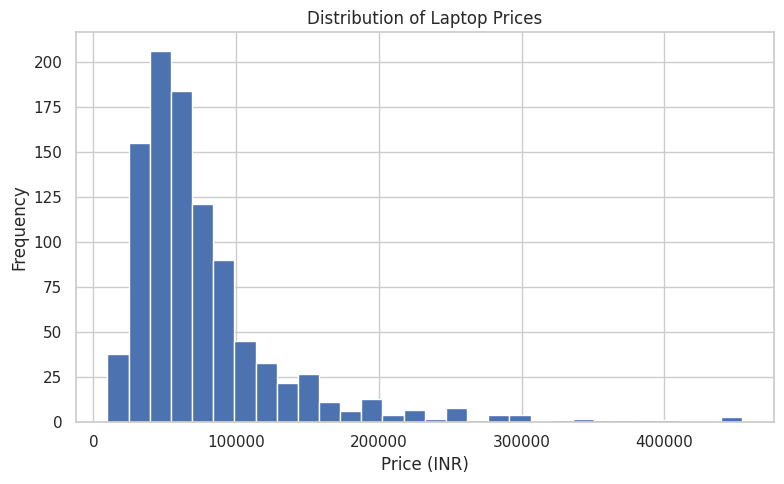

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["Price"], bins=30)
ax.set_title("Distribution of Laptop Prices")
ax.set_xlabel("Price (INR)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

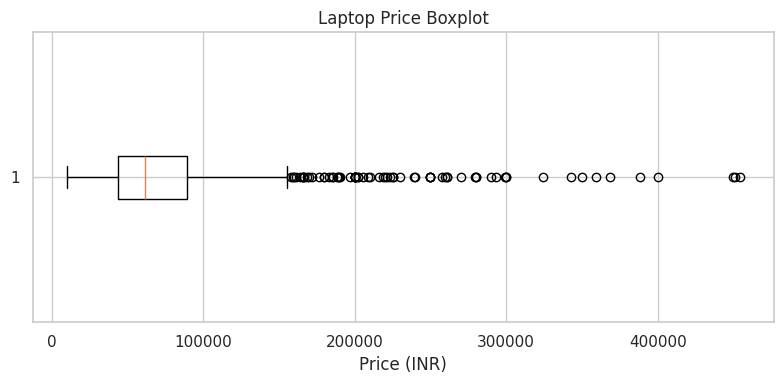

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(df["Price"], vert=False)
ax.set_title("Laptop Price Boxplot")
ax.set_xlabel("Price (INR)")
plt.tight_layout()
plt.show()

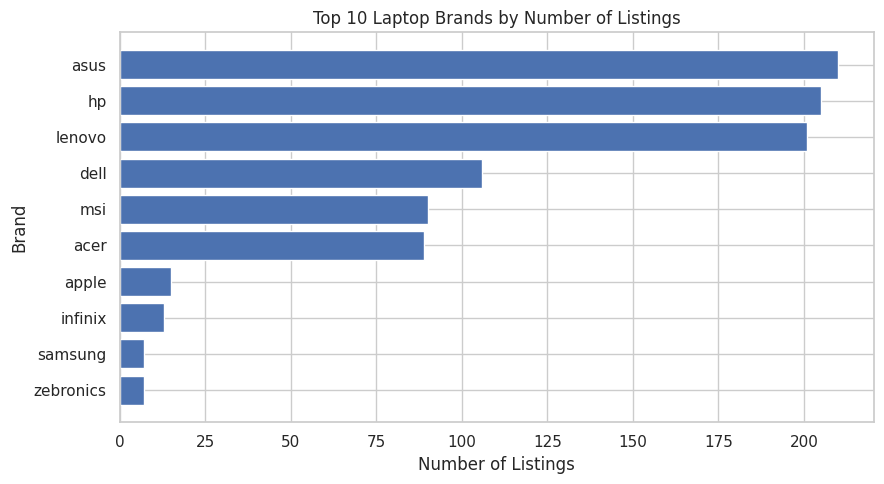

In [9]:
brand_counts = df["brand"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(brand_counts.index[::-1], brand_counts.values[::-1])
ax.set_title("Top 10 Laptop Brands by Number of Listings")
ax.set_xlabel("Number of Listings")
ax.set_ylabel("Brand")
plt.tight_layout()
plt.show()

### Univariate observations
- Most listings are concentrated in a moderate price range, while a smaller number of premium laptops create the long right tail.
- ASUS, HP and Lenovo are the most represented brands in the dataset.
- The boxplot highlights high-price observations that require investigation rather than automatic removal.

## 5. Bivariate Analysis

Scatter plots and grouped comparisons are used to examine relationships between individual specifications and price.

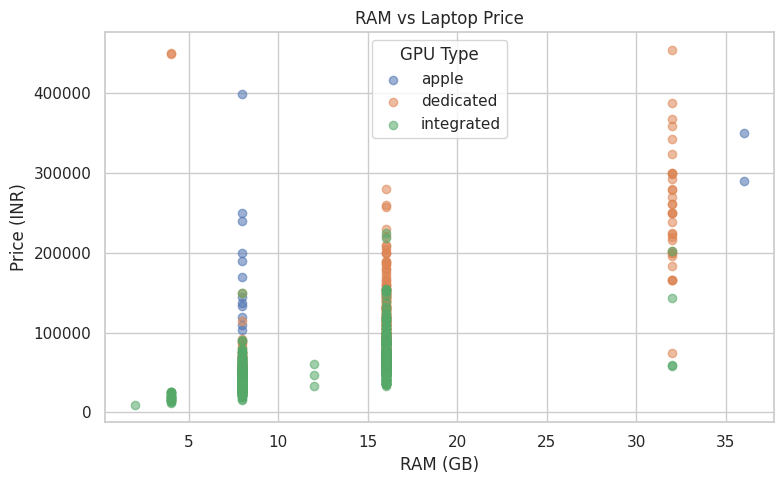

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for gpu_type, group in df.groupby("gpu_type"):
    ax.scatter(group["ram_memory"], group["Price"], alpha=0.55, label=gpu_type)
ax.set_title("RAM vs Laptop Price")
ax.set_xlabel("RAM (GB)")
ax.set_ylabel("Price (INR)")
ax.legend(title="GPU Type")
plt.tight_layout()
plt.show()

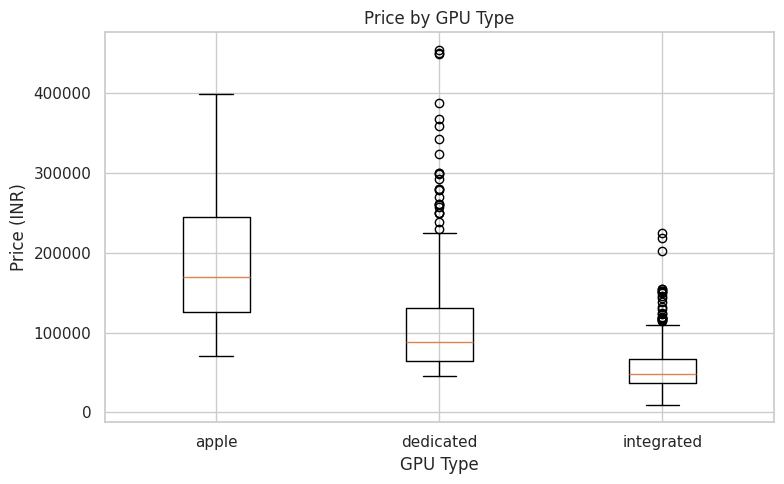

In [11]:
groups = [g["Price"].values for _, g in df.groupby("gpu_type")]
labels = [str(k) for k in df.groupby("gpu_type").groups.keys()]
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(groups, labels=labels)
ax.set_title("Price by GPU Type")
ax.set_xlabel("GPU Type")
ax.set_ylabel("Price (INR)")
plt.tight_layout()
plt.show()

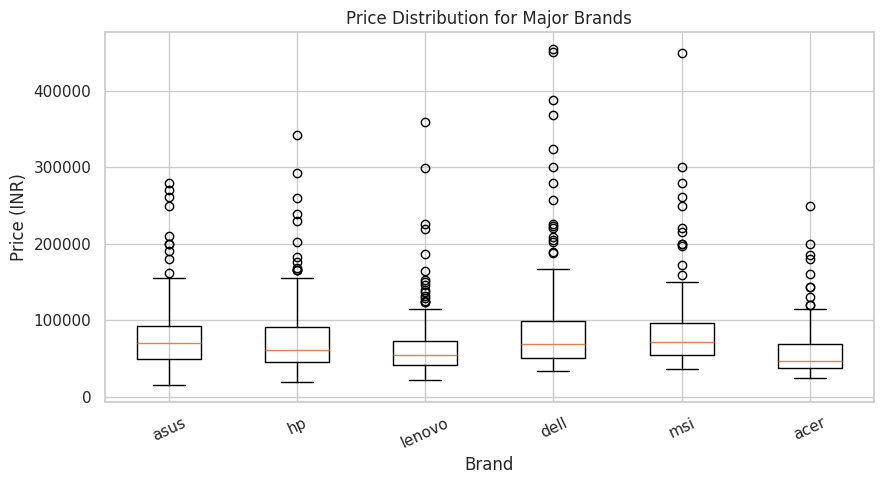

In [12]:
top_brands = df["brand"].value_counts().head(6).index
brand_price = df[df["brand"].isin(top_brands)]
groups = [brand_price.loc[brand_price["brand"] == b, "Price"].values for b in top_brands]
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(groups, labels=list(top_brands))
ax.set_title("Price Distribution for Major Brands")
ax.set_xlabel("Brand")
ax.set_ylabel("Price (INR)")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

### Bivariate observations
- Higher RAM configurations generally occur at higher prices.
- Dedicated GPUs are associated with a higher price distribution than integrated GPUs.
- Brand groups show different price distributions, indicating that brand is a useful categorical predictor.

## 6. Multivariate and Correlation Analysis

The course template recommends pair plots, parallel coordinates, Andrews curves and/or a correlation heatmap. We include a correlation heatmap and pair plot, and use parallel coordinates for a compact multivariate view.

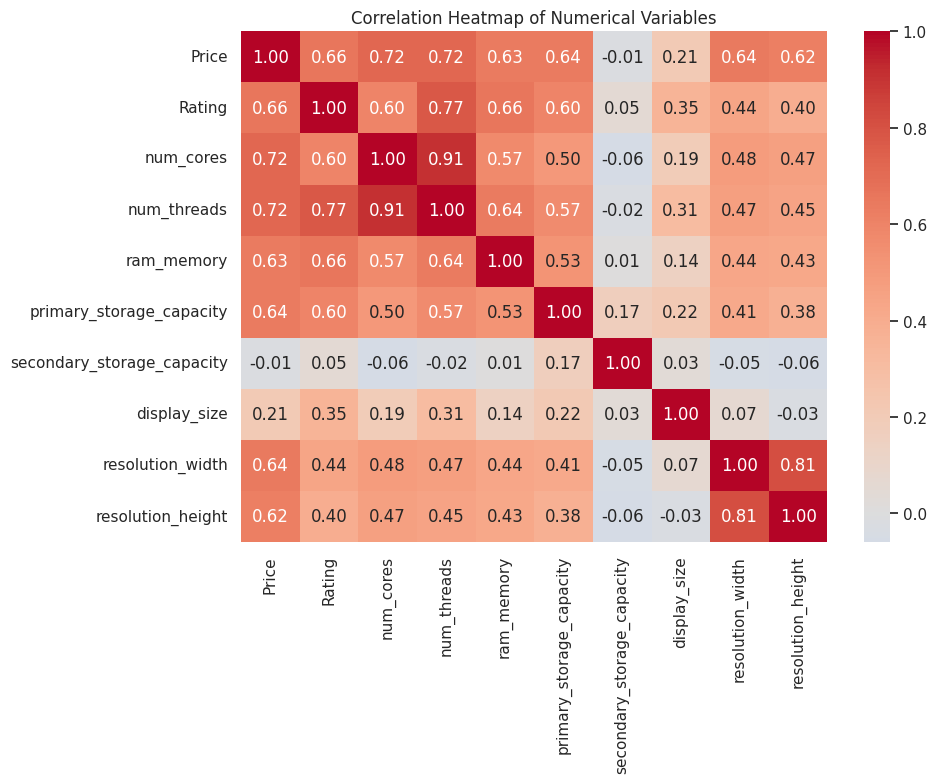

Correlations with Price:


,correlation
Price,1.000000
num_cores,0.724455
num_threads,0.719529
Rating,0.661422
resolution_width,0.640306
primary_storage_capacity,0.636343
ram_memory,0.633124
resolution_height,0.622278
display_size,0.211435
secondary_storage_capacity,-0.013604


In [13]:
corr_cols = ["Price", "Rating", "num_cores", "num_threads", "ram_memory",
             "primary_storage_capacity", "secondary_storage_capacity",
             "display_size", "resolution_width", "resolution_height"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

print("Correlations with Price:")
display(corr["Price"].sort_values(ascending=False).to_frame("correlation"))

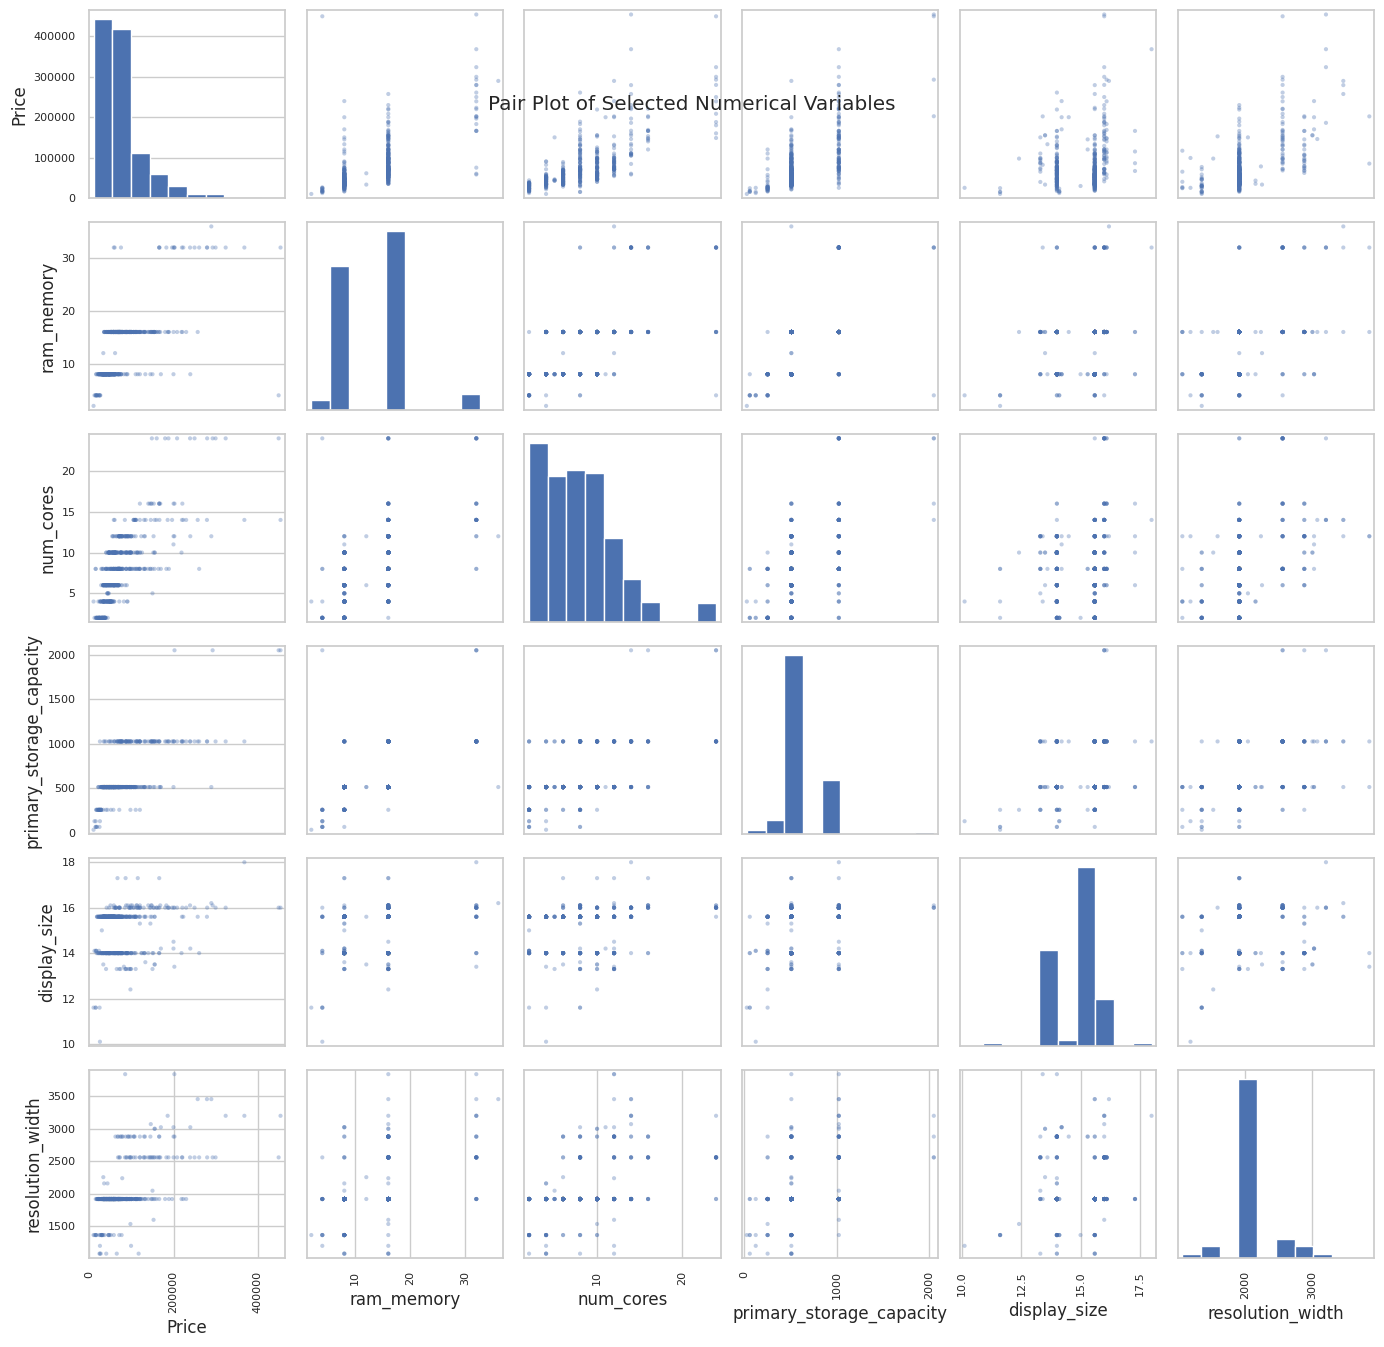

In [14]:
from pandas.plotting import scatter_matrix
pair_cols = ["Price", "ram_memory", "num_cores", "primary_storage_capacity", "display_size", "resolution_width"]
sample = df[pair_cols].sample(min(500, len(df)), random_state=42)
axes = scatter_matrix(sample, figsize=(14, 14), diagonal="hist", alpha=0.35)
plt.suptitle("Pair Plot of Selected Numerical Variables", y=0.90)
plt.tight_layout()
plt.show()

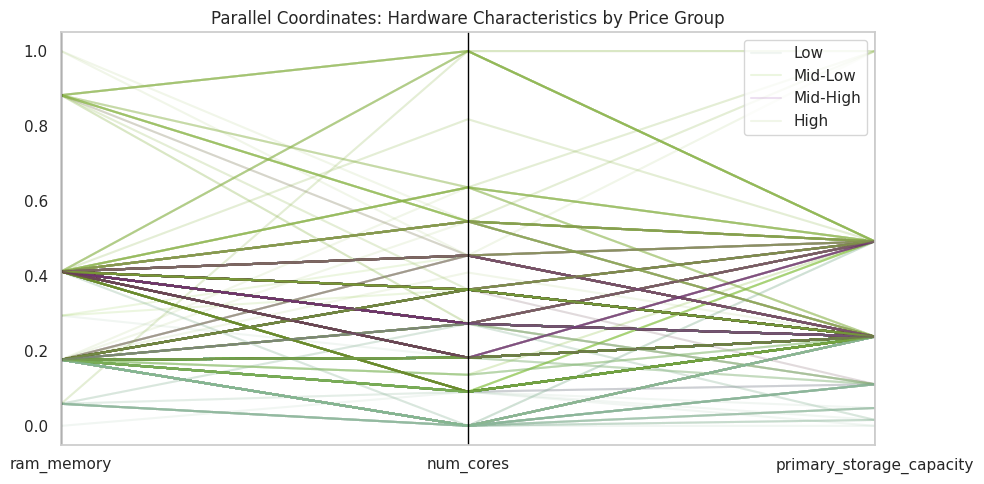

In [15]:
from pandas.plotting import parallel_coordinates

pc = df[["Price", "ram_memory", "num_cores", "primary_storage_capacity"]].copy()
# Use price quartiles as a categorical grouping for visualization
pc["Price_Group"] = pd.qcut(pc["Price"], q=4, labels=["Low", "Mid-Low", "Mid-High", "High"])
# Normalize numeric columns for comparability in the parallel-coordinate plot
plot_cols = ["ram_memory", "num_cores", "primary_storage_capacity"]
pc_plot = pc[["Price_Group"] + plot_cols].copy()
for col in plot_cols:
    lo, hi = pc_plot[col].min(), pc_plot[col].max()
    pc_plot[col] = (pc_plot[col] - lo) / (hi - lo)

fig, ax = plt.subplots(figsize=(10, 5))
parallel_coordinates(pc_plot, "Price_Group", ax=ax, alpha=0.12)
ax.set_title("Parallel Coordinates: Hardware Characteristics by Price Group")
plt.tight_layout()
plt.show()

### Multivariate observations
- Number of cores, RAM, storage capacity and resolution width show positive associations with price.
- `num_cores` and `num_threads` are strongly related, so both do not need to be included in the final specification model.
- The pair plot and parallel-coordinate view show that high-price groups tend to contain stronger hardware configurations, although the relationships are not perfectly linear.

## 7. Outlier Analysis

Outliers are identified using the IQR rule on the target price. Outlier status is not automatically treated as an error: unusually expensive laptops can be legitimate premium products.

In [16]:
q1 = df["Price"].quantile(0.25)
q3 = df["Price"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df["Price"] < lower_bound) | (df["Price"] > upper_bound)]

print(f"Q1: INR {q1:,.2f}")
print(f"Q3: INR {q3:,.2f}")
print(f"IQR: INR {iqr:,.2f}")
print(f"Lower bound: INR {lower_bound:,.2f}")
print(f"Upper bound: INR {upper_bound:,.2f}")
print(f"Potential price outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

display(outliers[["brand", "Model", "Price", "ram_memory", "num_cores", "gpu_type"]].sort_values("Price", ascending=False).head(10))

Q1: INR 43,595.00
Q3: INR 89,245.00
IQR: INR 45,650.00
Lower bound: INR -24,880.00
Upper bound: INR 157,720.00
Potential price outliers: 71 (7.16%)


,brand,Model,Price,ram_memory,num_cores,gpu_type
601,dell,Dell Alienware X16 Gaming Laptop (13th Gen Cor...,454490,32,14,dedicated
608,dell,Dell Alienware M18 R1 2023 Gaming Laptop (13th...,450990,4,24,dedicated
404,msi,MSI CreatorPro Z16 HX B13VKTO-214IN Laptop (13...,449990,4,24,dedicated
22,apple,Apple MacBook Pro 16 2023 Laptop (Apple M3 Max...,399900,8,16,apple
845,dell,Dell Alienware X16 R1 Gaming Laptop (13th Gen ...,388490,32,14,dedicated
847,dell,Dell Alienware M18 R1 Gaming Laptop (13th Gen ...,368490,32,14,dedicated
340,lenovo,Lenovo Legion Pro 7 82WQ007UIN Gaming Laptop (...,359095,32,24,dedicated
142,apple,Apple MacBook Pro 16 2023 Laptop (Apple M3 Max...,349900,36,14,apple
369,hp,HP Omen 17-ck2011TX Gaming Laptop (13th Gen Co...,342500,32,24,dedicated
603,dell,Dell Alienware X16 R1 2023 Gaming Laptop (13th...,323990,32,24,dedicated


### Outlier conclusion
The IQR method flags a relatively small set of high-price observations. These are plausible premium laptop listings rather than automatically invalid records, so they are **retained**. Removing them would discard meaningful information about the upper end of the laptop market.

## 8. Feature Engineering and Final ML Features

The final prediction pipeline follows the feature set already used by the project's React frontend through `export_model.py`. The goal is to keep the notebook model and deployed browser model consistent.

In [17]:
NUMERIC_FEATURES = [
    "ram_memory",
    "primary_storage_capacity",
    "num_cores",
    "display_size",
    "resolution_width",
    "resolution_height",
    "is_touch",
]

CATEGORICAL_FEATURES = [
    "brand",
    "processor_brand",
    "processor_tier",
    "primary_storage_type",
    "gpu_brand",
    "gpu_type",
    "OS",
    "year_of_warranty",
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "Price"

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("Numerical features:", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)
print("X shape:", X.shape)
print("y shape:", y.shape)

Numerical features: ['ram_memory', 'primary_storage_capacity', 'num_cores', 'display_size', 'resolution_width', 'resolution_height', 'is_touch']
Categorical features: ['brand', 'processor_brand', 'processor_tier', 'primary_storage_type', 'gpu_brand', 'gpu_type', 'OS', 'year_of_warranty']
X shape: (991, 15)
y shape: (991,)


### Feature-selection rationale
- `Rating` is excluded because it is not a hardware specification and reduced predictive performance in the existing deployment experiment.
- `Model` is excluded because every listing has a unique model/title, which would not generalize well to unseen products.
- Secondary storage is excluded because 976/991 listings have no secondary drive, making it low-information for the final buyer-facing model.
- `num_threads` is excluded because it closely tracks `num_cores` and was not retained in the deployment pipeline.
- The selected features match the existing `export_model.py` and therefore keep the final notebook and frontend consistent.

## 9. Train/Test Split and Preprocessing

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), CATEGORICAL_FEATURES),
    ]
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (792, 15)
Testing set: (199, 15)


## 10. Regression Model Comparison

The project proposal calls for comparison of Linear Regression, Random Forest Regressor and Gradient Boosting/XGBoost. All models use the same train/test split and preprocessing so the comparison is fair.

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300, random_state=42, n_jobs=-1
        ))
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=6,
            random_state=42, n_jobs=-1, objective="reg:squarederror"
        ))
    ])
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

print("All models trained successfully.")

Training Linear Regression...
Training Random Forest...


Training XGBoost...
All models trained successfully.


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
for name, model in models.items():
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
display(results_df.round(2))

,Model,MAE,RMSE,R2
1,Random Forest,11350.63,18264.65,0.90
0,Linear Regression,13862.22,19794.58,0.88
2,XGBoost,12121.99,21236.56,0.86


### Model comparison interpretation
The three algorithms are evaluated with MAE, RMSE and R². **Random Forest is expected to provide the strongest predictive performance on this dataset**, while Linear Regression provides a transparent coefficient-based model that can be exported directly to the existing browser frontend. The final deployment model is therefore selected with both predictive performance and interpretability/deployment consistency in mind.

## 11. Five-Fold Cross-Validation

In [21]:
from sklearn.model_selection import cross_validate

cv_rows = []
for name, model in models.items():
    scores = cross_validate(
        model, X, y, cv=5,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=-1
    )
    cv_rows.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R2": scores["test_R2"].mean()
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values("CV R2", ascending=False)
display(cv_results_df.round(2))

,Model,CV MAE,CV RMSE,CV R2
1,Random Forest,13056.03,24294.46,0.81
2,XGBoost,13242.19,24644.69,0.81
0,Linear Regression,15605.76,25463.46,0.80


## 12. Final Deployment Model: Linear Regression

Although Random Forest may score higher on predictive metrics, the project frontend currently reconstructs a Linear Regression model in the browser from its intercept, scaler parameters and one-hot coefficients. Therefore **Linear Regression is retained as the final deployed model** for consistency, transparency and explainability. The model comparison remains documented rather than hiding the stronger experimental model.

In [22]:
linear_model = models["Linear Regression"]
linear_pred = linear_model.predict(X_test)

final_mae = mean_absolute_error(y_test, linear_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
final_r2 = r2_score(y_test, linear_pred)

print(f"Final deployment model: Linear Regression")
print(f"Test MAE: INR {final_mae:,.2f}")
print(f"Test RMSE: INR {final_rmse:,.2f}")
print(f"Test R²: {final_r2:.3f}")

Final deployment model: Linear Regression
Test MAE: INR 13,862.22
Test RMSE: INR 19,794.58
Test R²: 0.877


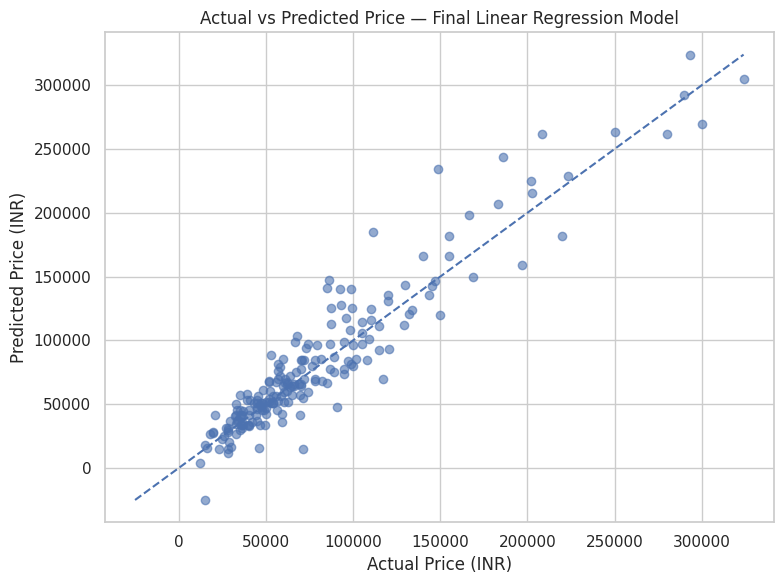

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, linear_pred, alpha=0.6)
min_price = min(y_test.min(), linear_pred.min())
max_price = max(y_test.max(), linear_pred.max())
ax.plot([min_price, max_price], [min_price, max_price], linestyle="--")
ax.set_xlabel("Actual Price (INR)")
ax.set_ylabel("Predicted Price (INR)")
ax.set_title("Actual vs Predicted Price — Final Linear Regression Model")
plt.tight_layout()
plt.show()

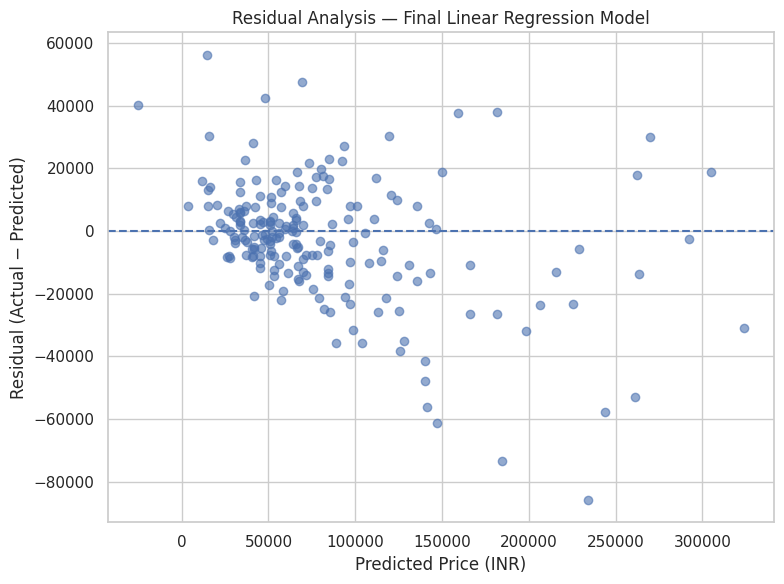

In [24]:
residuals = y_test - linear_pred
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(linear_pred, residuals, alpha=0.6)
ax.axhline(0, linestyle="--")
ax.set_xlabel("Predicted Price (INR)")
ax.set_ylabel("Residual (Actual − Predicted)")
ax.set_title("Residual Analysis — Final Linear Regression Model")
plt.tight_layout()
plt.show()

### Model diagnostic interpretation
The actual-vs-predicted plot shows how closely predictions follow the ideal diagonal. The residual plot checks whether errors are centered around zero and whether error spread changes with price. Some larger errors are expected for premium configurations because the price distribution is strongly right-skewed.

## 13. Explainability / Feature Importance

Permutation importance is used on the final Linear Regression pipeline to estimate how much predictive performance decreases when each original input feature is shuffled.

,Feature,Importance
9,processor_tier,0.1925
2,num_cores,0.0777
0,ram_memory,0.0479
1,primary_storage_capacity,0.0441
8,processor_brand,0.0419
7,brand,0.0274
11,gpu_brand,0.0241
4,resolution_width,0.0160
13,OS,0.0086
5,resolution_height,0.0066


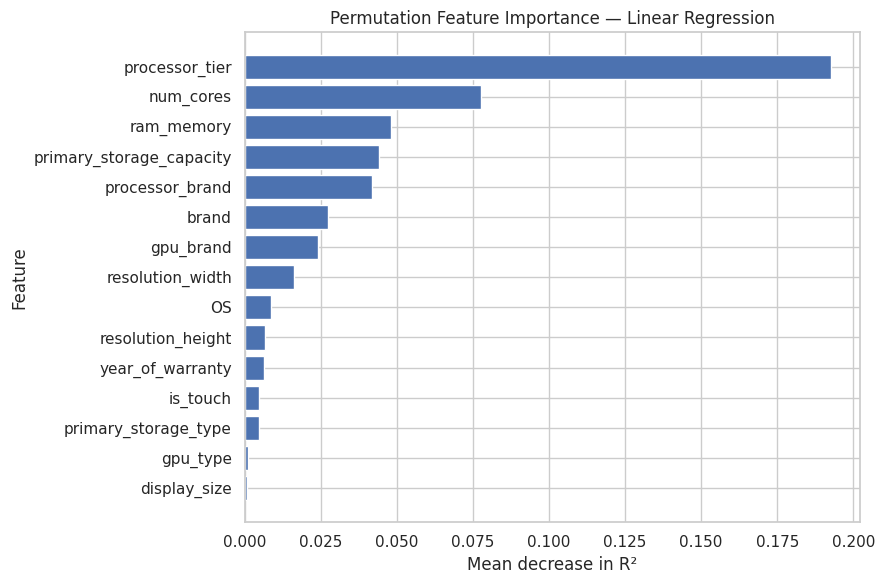

In [25]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    linear_model, X_test, y_test, scoring="r2",
    n_repeats=10, random_state=42, n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

display(importance_df.round(4))

fig, ax = plt.subplots(figsize=(9, 6))
plot_df = importance_df.sort_values("Importance")
ax.barh(plot_df["Feature"], plot_df["Importance"])
ax.set_xlabel("Mean decrease in R²")
ax.set_ylabel("Feature")
ax.set_title("Permutation Feature Importance — Linear Regression")
plt.tight_layout()
plt.show()

## 14. Fair-Price Estimation and Value Analysis

The selected deployment model is used to estimate a fair/expected price. To reduce overly optimistic in-sample estimates, fair prices are generated with **5-fold out-of-fold predictions** rather than predicting each training row with a model that already saw that row.

In [26]:
from sklearn.model_selection import cross_val_predict

oof_predictions = cross_val_predict(
    linear_model, X, y, cv=5, method="predict", n_jobs=-1
)

df_value = df.copy()
df_value["fair_price"] = oof_predictions
df_value["price_difference"] = df_value["Price"] - df_value["fair_price"]
df_value["price_difference_pct"] = (
    df_value["price_difference"] / df_value["fair_price"]
) * 100

def classify_value(pct):
    if pct < -10:
        return "Potentially Underpriced"
    elif pct <= 10:
        return "Fairly Priced"
    return "Potentially Overpriced"

df_value["value_category"] = df_value["price_difference_pct"].apply(classify_value)

value_counts = df_value["value_category"].value_counts()
value_summary = pd.DataFrame({
    "Count": value_counts,
    "Percentage": value_counts / len(df_value) * 100
})
display(value_summary.round(2))

,Count,Percentage
value_category,,
Potentially Underpriced,355,35.82
Fairly Priced,333,33.60
Potentially Overpriced,303,30.58


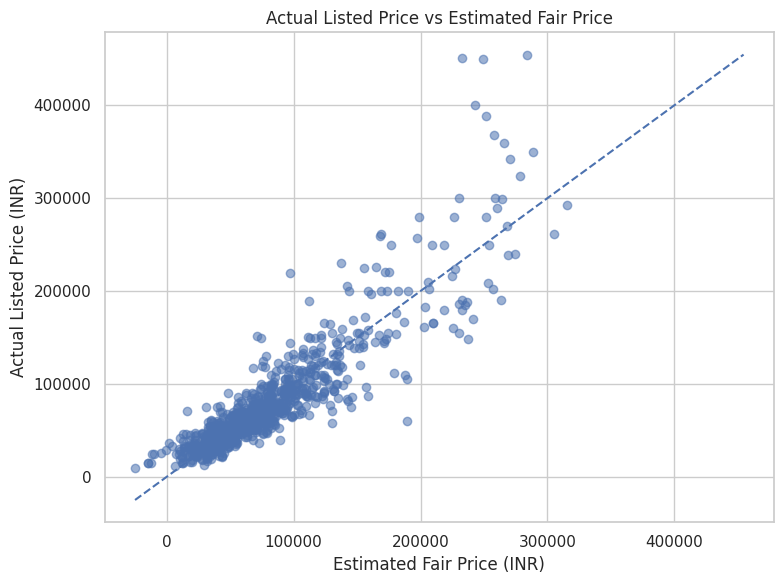

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_value["fair_price"], df_value["Price"], alpha=0.55)
min_price = min(df_value["fair_price"].min(), df_value["Price"].min())
max_price = max(df_value["fair_price"].max(), df_value["Price"].max())
ax.plot([min_price, max_price], [min_price, max_price], linestyle="--")
ax.set_xlabel("Estimated Fair Price (INR)")
ax.set_ylabel("Actual Listed Price (INR)")
ax.set_title("Actual Listed Price vs Estimated Fair Price")
plt.tight_layout()
plt.show()

In [28]:
display_columns = [
    "brand", "Model", "processor_tier", "ram_memory",
    "primary_storage_capacity", "gpu_type", "Price", "fair_price",
    "price_difference", "price_difference_pct", "value_category"
]

underpriced = df_value[df_value["value_category"] == "Potentially Underpriced"].sort_values("price_difference").head(10)
overpriced = df_value[df_value["value_category"] == "Potentially Overpriced"].sort_values("price_difference", ascending=False).head(10)

print("Top 10 potentially underpriced laptops")
display(underpriced[display_columns].round(2))

print("Top 10 potentially overpriced laptops")
display(overpriced[display_columns].round(2))

Top 10 potentially underpriced laptops


,brand,Model,processor_tier,ram_memory,primary_storage_capacity,gpu_type,Price,fair_price,price_difference,price_difference_pct,value_category
9,infinix,Infinix Zerobook 2023 Laptop (13th Gen Core i9...,core i9,32,1024,integrated,59990,189434.48,-129444.48,-68.33,Potentially Underpriced
139,dell,Dell 5530 G15 Gaming Laptop (13th Gen Core i9/...,core i9,16,1024,dedicated,148490,237087.22,-88597.22,-37.37,Potentially Underpriced
240,asus,Asus Vivobook S15 OLED 2023 S5504VA-MA953WS La...,core i9,16,1024,integrated,105739,189663.36,-83924.36,-44.25,Potentially Underpriced
386,lenovo,Lenovo IdeaPad Pro 5 83AQ005SIN Gaming Laptop ...,core i7,16,1024,dedicated,109190,187995.60,-78805.60,-41.92,Potentially Underpriced
116,asus,Asus Vivobook Pro 16 OLED 2023 K6602VU-LZ952WS...,core i9,16,1024,dedicated,154990,230515.27,-75525.27,-32.76,Potentially Underpriced
322,apple,Apple MacBook Pro 14 2023 Laptop (Apple M3/ 8G...,m3,8,1024,apple,189900,263379.71,-73479.71,-27.90,Potentially Underpriced
109,infinix,Infinix Zerobook 13 ZL513 2023 Laptop (13th Ge...,core i7,32,1024,integrated,57990,129912.91,-71922.91,-55.36,Potentially Underpriced
413,asus,Asus Vivobook 16 2023 X1605VA-MB957WS Laptop (...,core i9,16,1024,integrated,86689,158293.66,-71604.66,-45.24,Potentially Underpriced
332,apple,Apple MacBook Pro 14 2023 Laptop (Apple M3/ 8G...,m3,8,512,apple,169900,241243.84,-71343.84,-29.57,Potentially Underpriced
90,msi,MSI Katana 15 B13UDXK-1482IN Gaming Laptop (13...,core i5,32,1024,dedicated,74990,145328.92,-70338.92,-48.40,Potentially Underpriced


Top 10 potentially overpriced laptops


,brand,Model,processor_tier,ram_memory,primary_storage_capacity,gpu_type,Price,fair_price,price_difference,price_difference_pct,value_category
608,dell,Dell Alienware M18 R1 2023 Gaming Laptop (13th...,core i9,4,1024,dedicated,450990,232698.11,218291.89,93.81,Potentially Overpriced
404,msi,MSI CreatorPro Z16 HX B13VKTO-214IN Laptop (13...,core i9,4,2048,dedicated,449990,249174.82,200815.18,80.59,Potentially Overpriced
601,dell,Dell Alienware X16 Gaming Laptop (13th Gen Cor...,core i9,32,2048,dedicated,454490,283569.11,170920.89,60.27,Potentially Overpriced
22,apple,Apple MacBook Pro 16 2023 Laptop (Apple M3 Max...,m3,8,1024,apple,399900,243201.05,156698.95,64.43,Potentially Overpriced
845,dell,Dell Alienware X16 R1 Gaming Laptop (13th Gen ...,core i9,32,1024,dedicated,388490,251951.00,136539.00,54.19,Potentially Overpriced
316,lenovo,Lenovo ThinkPad X1 Carbon 21HMS00000 Laptop (1...,core i7,16,1024,integrated,218990,97000.24,121989.76,125.76,Potentially Overpriced
847,dell,Dell Alienware M18 R1 Gaming Laptop (13th Gen ...,core i9,32,1024,dedicated,368490,258000.05,110489.95,42.83,Potentially Overpriced
340,lenovo,Lenovo Legion Pro 7 82WQ007UIN Gaming Laptop (...,core i9,32,1024,dedicated,359095,265857.14,93237.86,35.07,Potentially Overpriced
633,hp,HP ZBook Studio G9 16 WUXGA Workstation Laptop...,core i7,16,1024,dedicated,230060,137545.20,92514.80,67.26,Potentially Overpriced
807,asus,Asus ROG Zephyrus G14 2023 GA402XZ-N2020WS Gam...,ryzen 9,32,1024,dedicated,260990,168743.26,92246.74,54.67,Potentially Overpriced


### Value-analysis interpretation
A laptop is labeled **Potentially Underpriced** when its listed price is more than 10% below the model-estimated fair price, **Fairly Priced** when it lies within ±10%, and **Potentially Overpriced** when it is more than 10% above the estimate. These are model-based indications, not guarantees of a good or bad purchase, because factors outside the available specifications can affect market price.

## 15. Key Findings and Conclusion

1. The dataset contains **991 Indian laptop listings and 22 raw attributes**, providing both numerical and categorical variables for EDA.
2. The price distribution is strongly right-skewed, with a smaller number of premium laptops producing the upper tail.
3. RAM, processor/core capacity, storage capacity and display resolution show meaningful positive relationships with price.
4. Dedicated GPUs and stronger hardware configurations tend to occur in higher-priced laptops.
5. Brand is an important categorical signal because major brands have visibly different price distributions.
6. The IQR method identifies high-price observations, but they are retained because premium laptops can be legitimate market observations.
7. Multiple regression models were compared using MAE, RMSE and R², with five-fold cross-validation providing a more robust comparison.
8. Linear Regression is retained as the final deployed model because it is transparent and can be reproduced exactly in the existing React frontend from exported coefficients.
9. Fair-price estimation and a ±10% value rule extend the project from simple prediction to decision support.

In [29]:
print("=" * 65)
print("FINAL PROJECT SUMMARY")
print("=" * 65)
print(f"Dataset: {len(df)} laptop listings")
print(f"Features used by final model: {len(FEATURES)}")
print(f"Final deployment model: Linear Regression")
print(f"Test MAE: INR {final_mae:,.2f}")
print(f"Test RMSE: INR {final_rmse:,.2f}")
print(f"Test R²: {final_r2:.3f}")
print("\nValue categories (5-fold out-of-fold fair prices):")
print(value_summary.round(2))
print("\nFair-price threshold: ±10%")
print("=" * 65)

FINAL PROJECT SUMMARY
Dataset: 991 laptop listings
Features used by final model: 15
Final deployment model: Linear Regression
Test MAE: INR 13,862.22
Test RMSE: INR 19,794.58
Test R²: 0.877

Value categories (5-fold out-of-fold fair prices):
                         Count  Percentage
value_category                            
Potentially Underpriced    355       35.82
Fairly Priced              333       33.60
Potentially Overpriced     303       30.58

Fair-price threshold: ±10%


## References

1. B. Jikadara, **Brand Laptops Dataset**, Kaggle.
2. BASCE301 Exploratory Data Analysis Course Project guidelines and presentation template.
3. Scikit-learn documentation for preprocessing, regression, cross-validation and evaluation metrics.
4. XGBoost documentation for gradient-boosting regression.
5. Project proposal: **Intelligent Laptop Price Prediction and Value Analysis Using Machine Learning**.